# Historical bias: coarse debiased vs. downscaled debiased vs. observations

**The goal of this notebook is to identify places where the spatial disaggregation (i.e., downscaling) step is hurting rather than helping.** Markdown text was generated with Claude based on rough notes and interview questions, then edited manually.

For a single historical variable/scenario/ensemble member, we compare how well the **coarse debiased** output and the **downscaled, debiased** compare to observations (ERA5) -- both at ERA5's native (fine) resolution and coarsened to the model's grid.

The entire point of downscaling is to add back fine-scale detail that debiasing at coarse resolution can't capture. So we expect:
- **Downscaled should beat coarse debiased when compared to fine-resolution obs.** This is the core test -- we expect downscaling to make data look better when compared to fine-resolution observations. If the **coarse** product looks better than the **downscaled** product in either comparison, that's a red flag: it means downscaling is making things worse, not better.
- **A re-coarsened downscaled dataset should ideally still beat coarse when both are compared to coarsened obs**, though this is a weaker expectation -- quality loss from spatially averaging a higher-resolution product is expected and less concerning

We measure "how well X reproduces obs" with a goodness-of-fit score -- `eval_metric` in Configuration below selects between R² relative to the 1:1 line (Nash-Sutcliffe efficiency) and Kling-Gupta Efficiency; see the "Compute climatology & goodness-of-fit metrics" section for how they differ -- computed on a **monthly (or smoothed day-of-year) climatology** rather than raw daily values. Precipitation is intermittent and event-driven, and this is a free-running historical simulation (not reanalysis nudged to match real-world weather) -- there's no reason a storm should land on the same calendar date in the model as in ERA5, even for a very good model. Comparing at raw daily resolution double-penalizes any timing offset (missed on the right day + false alarm on the wrong day), which drowns out the real seasonal-cycle signal. Averaging over a month, or smoothing over a rolling window of days, suppresses that timing noise and isolates genuine seasonal-cycle skill.

In [2]:
import icechunk
import matplotlib.pyplot as plt
import pandas as pd

from saidownscale import catalog
from saidownscale.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from saidownscale.qaqc import disagg_test_calculate_metrics
from saidownscale.utils import open_icechunk

## Configuration

Settings below are specific to this variable/scenario/ensemble member and this machine's output paths. Update these to rerun for a different variable or dataset.

In [3]:
# --- Data source ---
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
path_output = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.12.0"

# --- Variable / scenario / ensemble member ---
var = "rsds"
scenario = "historical"
ens = "r3i1p1f1"

# --- Evaluation metric ---
# Which goodness-of-fit metric (from disagg_test_calculate_metrics) drives
# every map, summary, and CSV export below.
# "r2_oneone" -> R² relative to the 1:1 line (Nash-Sutcliffe efficiency).
#                Single aggregate score; squared-error-based, so it rewards
#                simulations that underestimate variance and can't tell you
#                *why* a cell scores low.
# "kge"       -> Kling-Gupta Efficiency. Decomposes skill into correlation
#                (kge_r), variability ratio (kge_alpha), and bias ratio
#                (kge_beta) -- also available individually in the metrics
#                Dataset if you want to plot those separately. Its "no
#                better than the mean" benchmark is ~-0.41, not 0.
eval_metric = "kge"

# --- Plot color scales ---
# Both metrics: 1 = perfect. Ranges below are tuned per metric since their
# "no skill" floors differ (NSE: 0; KGE: ~-0.41) and so does their typical
# spread -- don't reuse one metric's scale for the other.
if eval_metric == "kge":
    metric_vmin, metric_vmax = 0.5, 1.0
    metric_label = "KGE"
else:
    metric_vmin, metric_vmax = 0.7, 1.0
    metric_label = "r2_oneone (NSE)"
# vmax for (downscaled metric - coarse metric) difference maps -- both the
# diverging map and the "where does downscaling win/lose" split maps. Fixed
# for now; revisit once you've seen the actual post-fix, monthly-scale values.
metric_diff_vmax = 0.3
metric_diff_label = f"Δ {metric_label} (downscaled − coarse)"

# --- Climatology aggregation method ---
# "month"     -> groupby calendar month (recommended default; see markdown
#                discussion above for why not raw daily/day-of-year values)
# "dayofyear" -> groupby day-of-year, then a centered, circular rolling-mean
#                smoother (window = rolling_window_days) to damp day-to-day
#                storm-timing noise while keeping more within-season detail
#                than monthly
time_dim = "dayofyear"  # note "dayofyear" option is very slow
rolling_window_days = 1  # only used when time_dim == "dayofyear"

## Load data

In [4]:
repo = icechunk.Repository.open(
    icechunk.s3_storage(
        bucket="us-west-2.opendata.source.coop",
        prefix="carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk/",
        region="us-west-2",
    )
)
print("Available branches:", repo.list_branches())
assert branch in repo.list_branches(), f"branch {branch!r} not found"

Available branches: {'main', 'v0.12.0'}


In [5]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]

debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [6]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

## Regrid onto matching resolutions

To isolate the effect of downscaling from the effect of resolution mismatch, we build four combinations:

| | vs. fine obs | vs. coarse obs |
|---|---|---|
| **coarse debiased output** | upsampled to fine grid (nearest-neighbor) | native |
| **downscaled, debiased output** | native | coarsened to match obs |

Comparing at both resolutions lets us separate two questions: does downscaling look better against real fine-scale detail (the resolution obs are actually observed at), and does it hold up even after that fine detail is averaged away again?

In [7]:
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()
coarse_debiased_finegrid = coarse_debiased.interp(
    lon=obs_fine["lon"],
    lat=obs_fine["lat"],
    method="nearest",
).compute()

fine = rechunk(
    debiased_downscaled, pattern="full_space"
).persist()  # -> (time≈25, lat=-1, lon=-1), ~100 MB/chunk
coarsened_debiased_downscaled = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine, da_coarse_grid=coarse_debiased
).compute()

In [8]:
from saidownscale import catalog

raw_hist = (
    catalog.get("CESM2-WACCM")
    .to_xarray()["historical"][var]
    .sel(ensemble_member=ens)
    .sel(time=slice("1978-01-01", "2014-12-31"))
)

## Compute climatology & goodness-of-fit metrics

For each grid cell, we collapse the historical time series to a climatology before comparing to obs. The method is set by `time_dim` in Configuration above:
- `"month"` (default): mean by calendar month. See the timescale discussion at the top of the notebook for why this is recommended over raw daily/day-of-year values.
- `"dayofyear"`: mean by calendar day, then a centered, circular `rolling_window_days`-wide rolling mean. Keeps more within-season resolution than monthly while still damping day-to-day storm-timing noise.

`disagg_test_calculate_metrics` computes both goodness-of-fit metrics regardless of which one you plot; `eval_metric` (Configuration above) just selects which one drives the maps/summary/CSV below:
- `r2_oneone`: R² relative to the 1:1 line (Nash-Sutcliffe efficiency), treating obs as ground truth. It's 1 for a perfect match, 0 if the product is no better than just guessing the observed mean, and can go negative if it's worse than that.
- `kge`: Kling-Gupta Efficiency, also 1 for a perfect match. Instead of one aggregate number, it decomposes skill into three parts -- correlation (`kge_r`), variability ratio (`kge_alpha`, i.e. is the seasonal cycle's spread over/under-dispersed), and mean-bias ratio (`kge_beta`) -- so a low score can be diagnosed rather than just observed. Those sub-components are also in the returned Dataset if you want to inspect them directly.

In [9]:
def agg_over_time(da, time_dim, rolling_window_days=10):
    """Climatology of da, grouped by time_dim ("month" or "dayofyear").

    For "dayofyear", also applies a centered rolling-mean smoother (window =
    rolling_window_days) to damp single-day storm-timing noise, wrapping
    across the Dec 31 / Jan 1 boundary so the smoothing is circular.
    """
    da_agg = da.groupby("time." + time_dim).mean().compute()
    if time_dim == "dayofyear":
        if rolling_window_days > 1:
            dayofyear = da_agg["dayofyear"]
            n = da_agg.sizes["dayofyear"]
            half = rolling_window_days // 2
            da_agg = da_agg.pad(dayofyear=half, mode="wrap")
            da_agg = da_agg.rolling(
                dayofyear=rolling_window_days, center=True, min_periods=1
            ).mean()
            da_agg = da_agg.isel(dayofyear=slice(half, half + n))
            da_agg = da_agg.assign_coords(dayofyear=dayofyear)
    return da_agg

In [10]:
# Two outputs on the fine grid
debiased_downscaled_clim = agg_over_time(
    debiased_downscaled, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()
coarse_debiased_finegrid_clim = agg_over_time(
    coarse_debiased_finegrid, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()

# Two outputs on the coarse grid
coarse_debiased_clim = agg_over_time(
    coarse_debiased, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()
coarsened_debiased_downscaled_clim = agg_over_time(
    coarsened_debiased_downscaled, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()

obs_fine_clim = agg_over_time(
    obs_fine, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()
obs_coarse_clim = agg_over_time(
    obs_coarse, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()


raw_hist_clim = agg_over_time(
    raw_hist, time_dim=time_dim, rolling_window_days=rolling_window_days
).compute()

In [11]:
metrics_obsfine_outputfine = disagg_test_calculate_metrics(
    x=obs_fine_clim, y=debiased_downscaled_clim, time_dim=time_dim
)
metrics_obsfine_outputcoarse = disagg_test_calculate_metrics(
    x=obs_fine_clim, y=coarse_debiased_finegrid_clim, time_dim=time_dim
)

metrics_obscoarse_outputfine = disagg_test_calculate_metrics(
    x=obs_coarse_clim, y=coarsened_debiased_downscaled_clim, time_dim=time_dim
)
metrics_obscoarse_outputcoarse = disagg_test_calculate_metrics(
    x=obs_coarse_clim, y=coarse_debiased_clim, time_dim=time_dim
)

metrics_obscoarse_rawgcm = disagg_test_calculate_metrics(
    x=obs_coarse_clim, y=raw_hist_clim, time_dim=time_dim
)

# Does debiasing improve the bias?
Yes! The debiasing does the heaviest lift, lifting the KGE substantially almost world wide.

Text(0.5, 1.0, 'Coarse debiased')

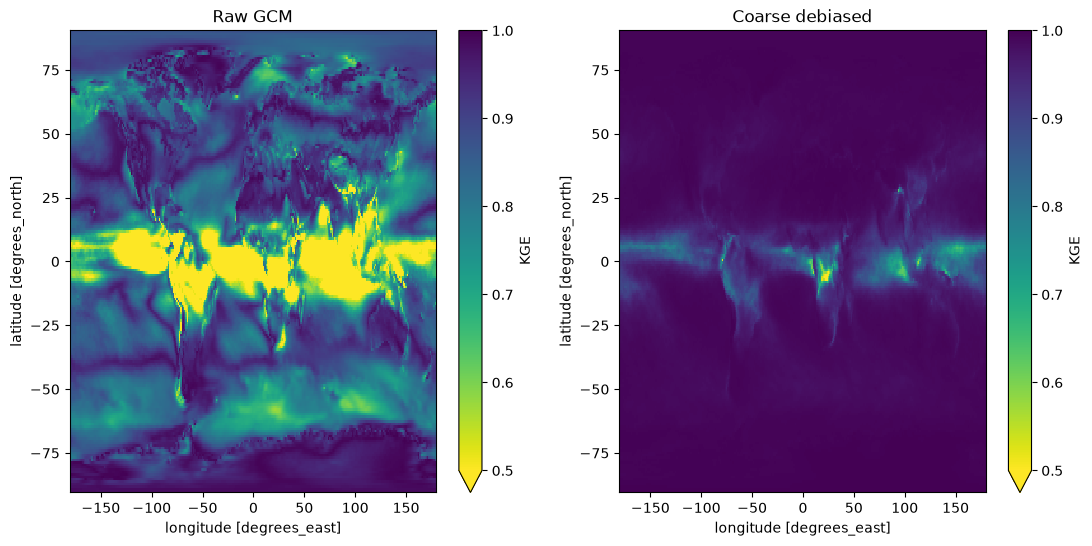

In [12]:
plt.figure(figsize=(13, 6))
plt.subplot(1, 2, 1)
metrics_obscoarse_rawgcm[eval_metric].plot(
    vmin=metric_vmin, vmax=metric_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": metric_label}
)
plt.title("Raw GCM")
plt.subplot(1, 2, 2)
metrics_obscoarse_outputcoarse[eval_metric].plot(
    vmin=metric_vmin, vmax=metric_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": metric_label}
)
plt.title("Coarse debiased")

# Does downscaling improve the bias?
Yes! But in way more limited ways than the bias-correction. Focused on mountains and coasts.

## Map goodness-of-fit (`eval_metric`) across all grid cells

- **(A)** and **(B)**: fine obs vs. fine (downscaled) output, and fine obs vs. coarse output upsampled to the fine grid -- the primary comparison, since it's against real observed spatial detail.
- **(D)** and **(E)**: the same comparison, but with obs and the downscaled output both coarsened to the model's native grid.
- **(A)-(B)** and **(D)-(E)**: downscaled minus coarse. Blue = downscaling helps; red = downscaling hurts.

The (A) - (B) panel indicates where you should go to the trouble of using downscaled data as opposed to just bias-corrected coarse output. Anywhere it's blue you could consider it since the downscaled data is more like reality than the coarse data. Anywhere it's white you might not even bother, since the coarse bias-adjusted data is just as good as the downscaled data. These blue areas largely align with areas of topographic variation like mountains and coasts.

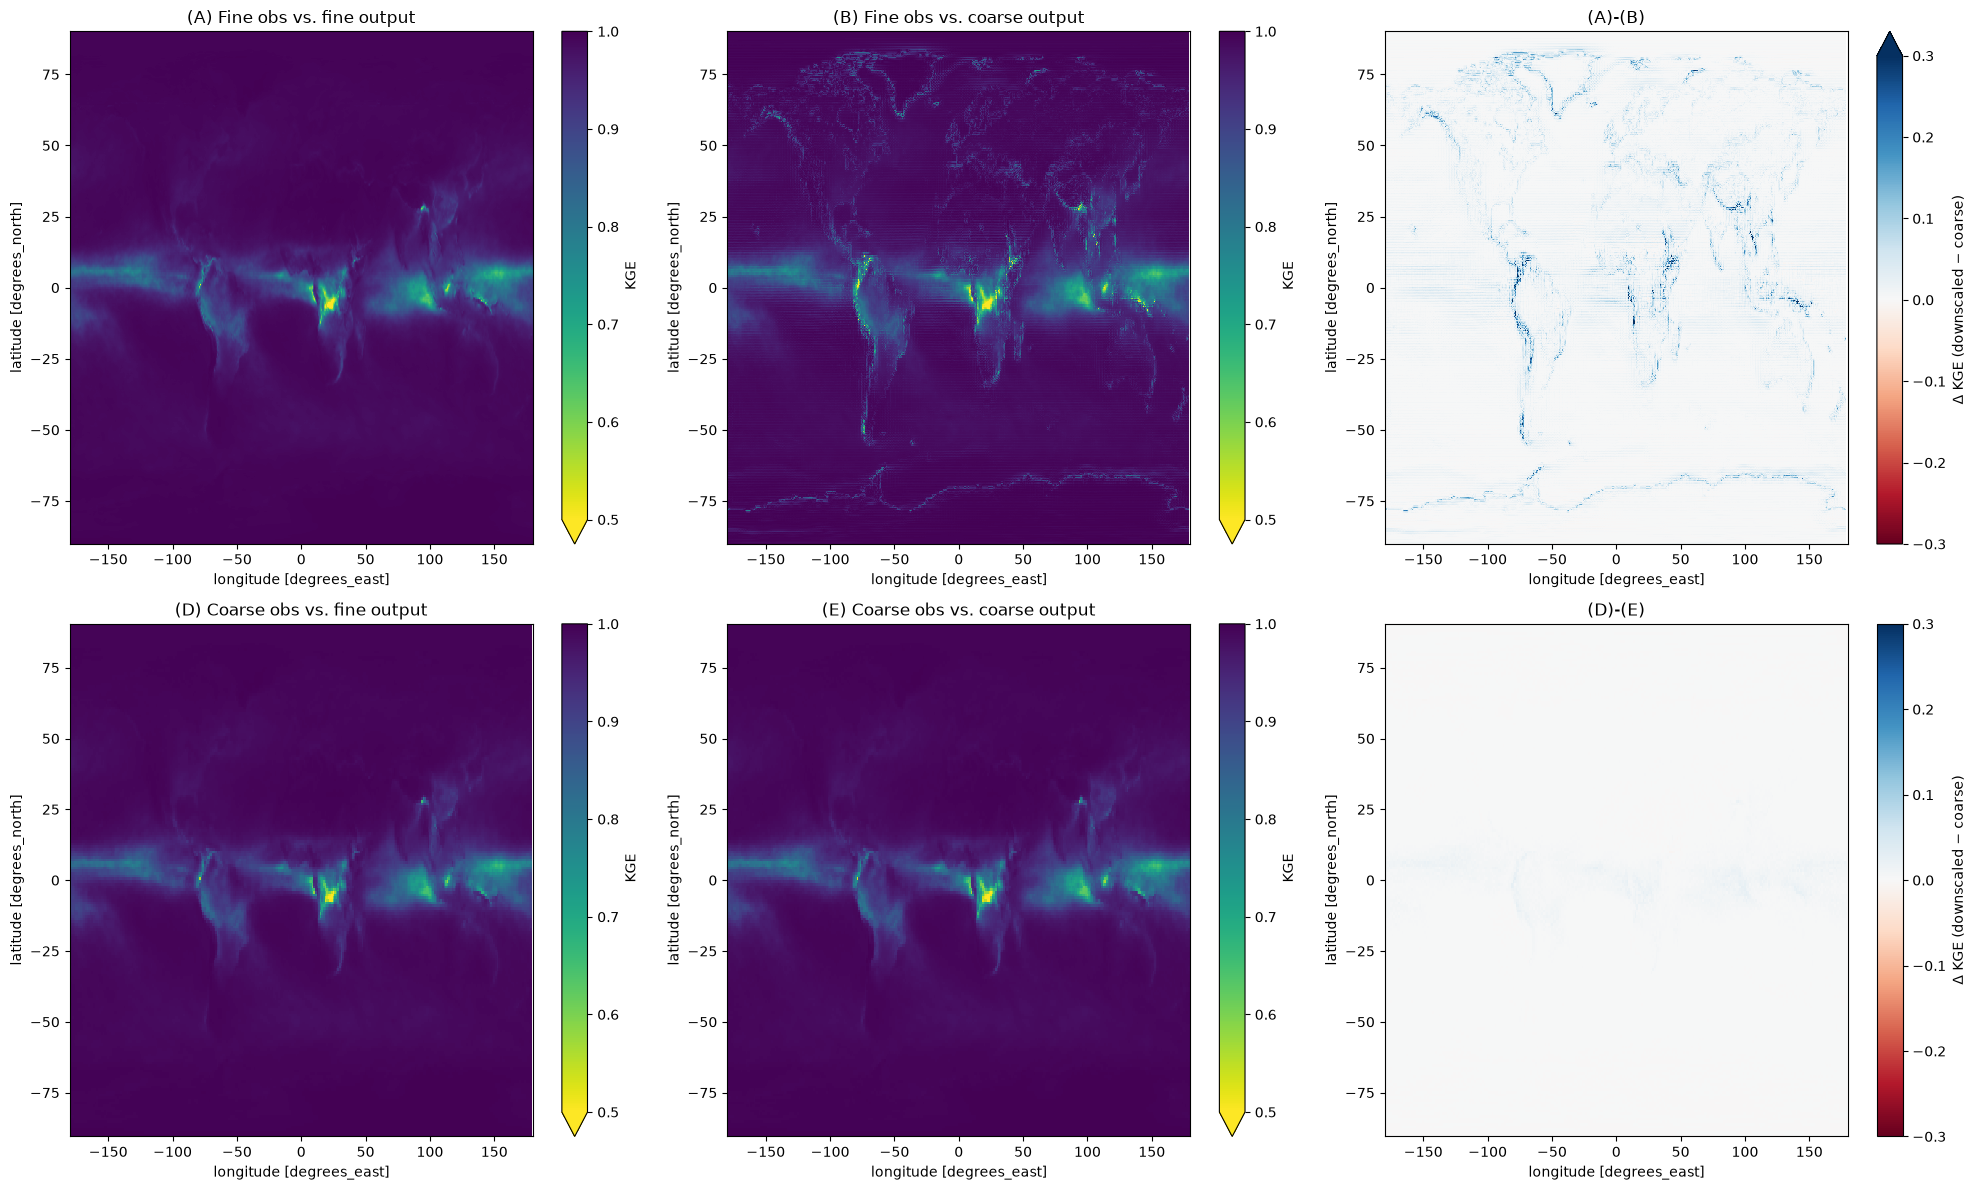

In [13]:
def format_subplot():
    plt.xlim([-180, 180])


plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1)
metrics_obsfine_outputfine[eval_metric].plot(
    vmin=metric_vmin, vmax=metric_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": metric_label}
)
plt.title("(A) Fine obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 2)
metrics_obsfine_outputcoarse[eval_metric].plot(
    vmin=metric_vmin, vmax=metric_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": metric_label}
)
plt.title("(B) Fine obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 3)
(metrics_obsfine_outputfine[eval_metric] - metrics_obsfine_outputcoarse[eval_metric]).plot(
    vmin=-metric_diff_vmax,
    vmax=metric_diff_vmax,
    cmap=plt.cm.RdBu,
    cbar_kwargs={"label": metric_diff_label},
)
plt.title("(A)-(B)")
format_subplot()
plt.subplot(2, 3, 4)
metrics_obscoarse_outputfine[eval_metric].plot(
    vmin=metric_vmin, vmax=metric_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": metric_label}
)
plt.title("(D) Coarse obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 5)
metrics_obscoarse_outputcoarse[eval_metric].plot(
    vmin=metric_vmin, vmax=metric_vmax, cmap=plt.cm.viridis_r, cbar_kwargs={"label": metric_label}
)
plt.title("(E) Coarse obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 6)
(metrics_obscoarse_outputfine[eval_metric] - metrics_obscoarse_outputcoarse[eval_metric]).plot(
    vmin=-metric_diff_vmax,
    vmax=metric_diff_vmax,
    cmap=plt.cm.RdBu,
    cbar_kwargs={"label": metric_diff_label},
)
plt.title("(D)-(E)")
format_subplot()
plt.tight_layout()
plt.savefig(path_qaqc + "hist_bias_maps_" + var + "_" + scenario + "_" + ens + ".png")

## Where exactly does downscaling help vs. hurt?

Same (downscaled − coarse) difference as above, but split into two panels per comparison so the sign is unambiguous: left = downscaling wins, right = downscaling loses. Gray = the other sign (masked out).

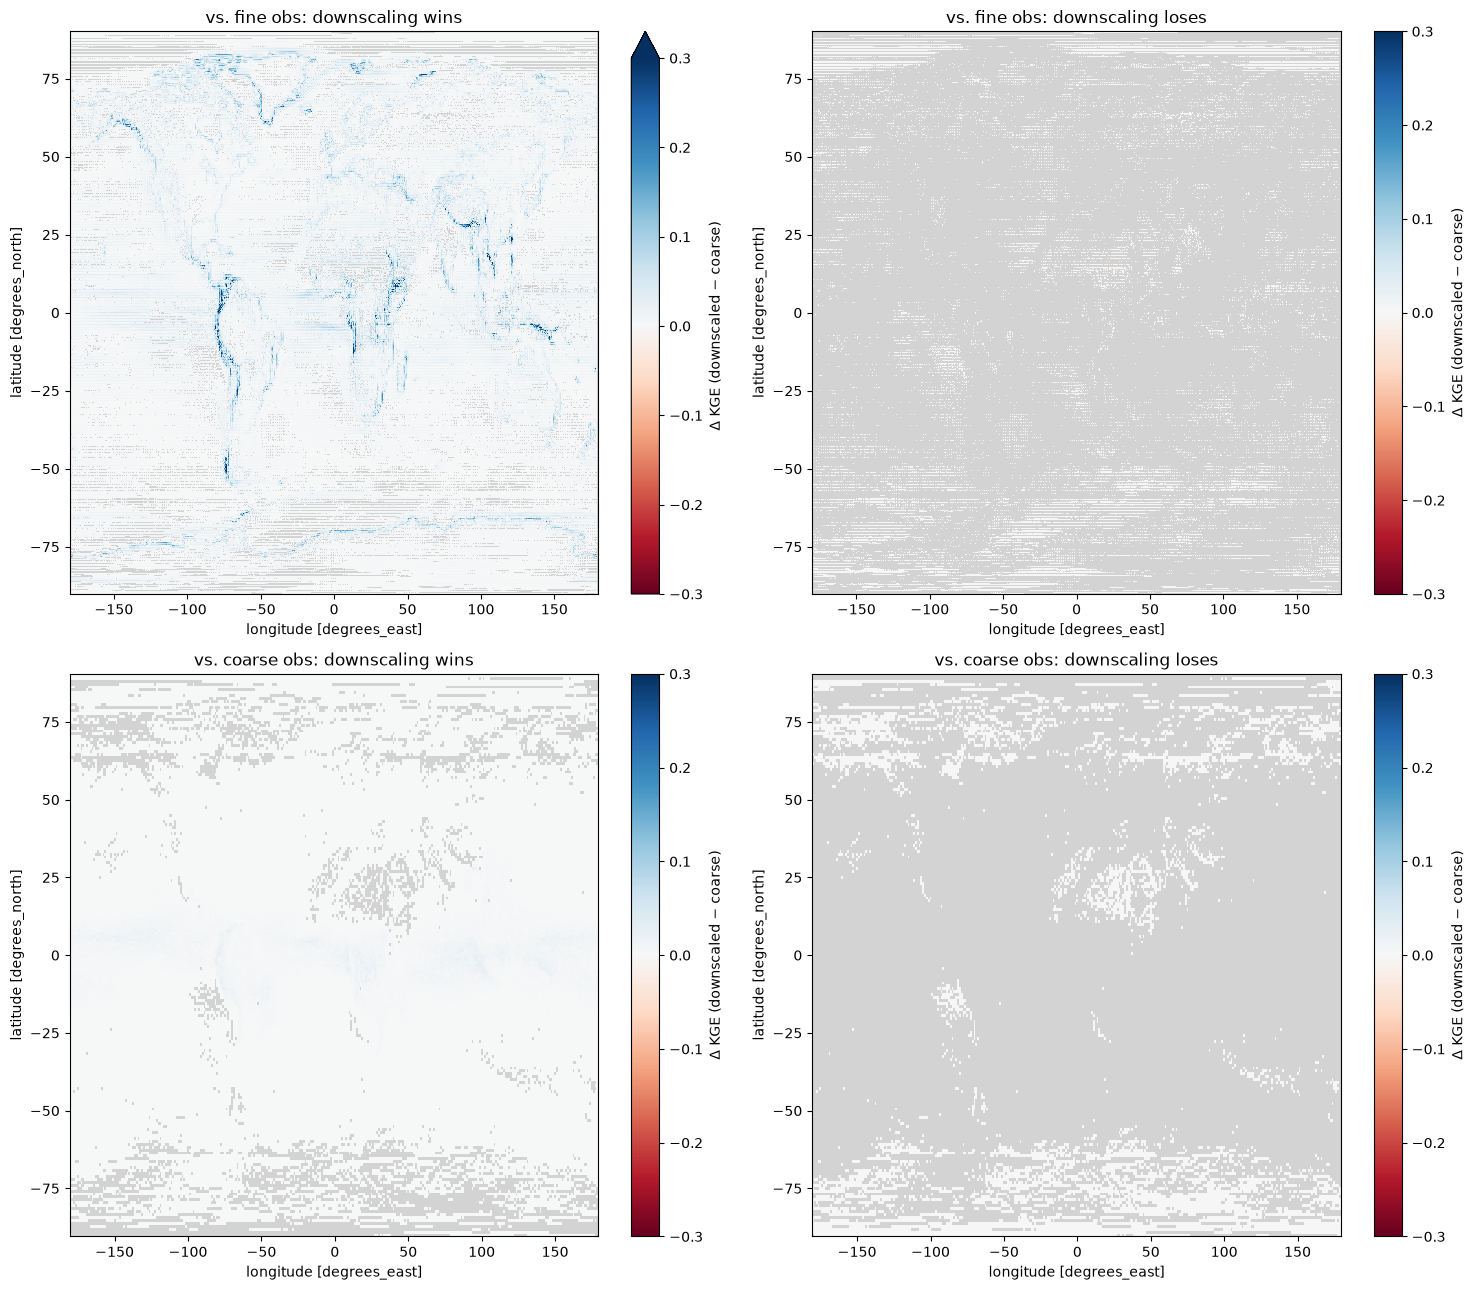

In [23]:
downscaled_vs_coarse_debiased_obsfine = (
    metrics_obsfine_outputfine[eval_metric] - metrics_obsfine_outputcoarse[eval_metric]
)
downscaled_vs_coarse_debiased_obscoarse = (
    metrics_obscoarse_outputfine[eval_metric] - metrics_obscoarse_outputcoarse[eval_metric]
)

plt.figure(figsize=(15, 13))
ax = plt.subplot(2, 2, 1)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obsfine.where(downscaled_vs_coarse_debiased_obsfine > 0).plot(
    vmax=metric_diff_vmax,
    vmin=-metric_diff_vmax,
    cmap=plt.cm.RdBu,
    cbar_kwargs={"label": metric_diff_label},
)
plt.title("vs. fine obs: downscaling wins")
ax = plt.subplot(2, 2, 2)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obsfine.where(downscaled_vs_coarse_debiased_obsfine < 0).plot(
    vmax=metric_diff_vmax,
    vmin=-metric_diff_vmax,
    cmap=plt.cm.RdBu,
    cbar_kwargs={"label": metric_diff_label},
)
plt.title("vs. fine obs: downscaling loses")
ax = plt.subplot(2, 2, 3)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obscoarse.where(downscaled_vs_coarse_debiased_obscoarse > 0).plot(
    vmax=metric_diff_vmax,
    vmin=-metric_diff_vmax,
    cmap=plt.cm.RdBu,
    cbar_kwargs={"label": metric_diff_label},
)
plt.title("vs. coarse obs: downscaling wins")
ax = plt.subplot(2, 2, 4)
ax.set_facecolor("lightgray")
downscaled_vs_coarse_debiased_obscoarse.where(downscaled_vs_coarse_debiased_obscoarse < 0).plot(
    vmax=metric_diff_vmax,
    vmin=-metric_diff_vmax,
    cmap=plt.cm.RdBu,
    cbar_kwargs={"label": metric_diff_label},
)
plt.title("vs. coarse obs: downscaling loses")
plt.tight_layout()

## Summary: is downscaling actually helping?

Recap of the framing from the top: downscaling should improve fidelity to observations, especially fine-resolution obs. Below: for each obs comparison, the fraction of the domain where downscaled beats coarse (and vice versa), plus the domain-mean value of `eval_metric` for all four combinations.

In [15]:
thresh = 0.01
print("Bias relative to fine-scale observations: coarse debiased vs. downscaled")
print("Fraction of area where downscaled output looks better than coarse output:")
frac_improved = (downscaled_vs_coarse_debiased_obsfine > thresh).mean().values
print(frac_improved)
print("Fraction of area where coarse output looks better than downscaled output:")
frac_worsened = (downscaled_vs_coarse_debiased_obsfine < -thresh).mean().values
print(frac_worsened)
print("Fraction of area where coarse output and downscaled output are equivalent:")
print(1 - frac_improved - frac_worsened)
print("------------------")
print(f"Domain-mean {metric_label}")
print("Fine obs vs. downscaled output:  ", metrics_obsfine_outputfine[eval_metric].mean().values)
print("Fine obs vs. coarse output:      ", metrics_obsfine_outputcoarse[eval_metric].mean().values)
print("Coarse obs vs. downscaled output:", metrics_obscoarse_outputfine[eval_metric].mean().values)
print(
    "Coarse obs vs. coarse output:    ", metrics_obscoarse_outputcoarse[eval_metric].mean().values
)

Bias relative to fine-scale observations: coarse debiased vs. downscaled
Fraction of area where downscaled output looks better than coarse output:
0.24104349668670058
Fraction of area where coarse output looks better than downscaled output:
0.00012232239173986747
Fraction of area where coarse output and downscaled output are equivalent:
0.7588341809215596
------------------
Domain-mean KGE
Fine obs vs. downscaled output:   0.9776781
Fine obs vs. coarse output:       0.96843463
Coarse obs vs. downscaled output: 0.9787274
Coarse obs vs. coarse output:     0.97759956


## Example: zoom into one point

A quick qualitative sanity check before looking at the maps -- the seasonal cycle of obs vs. each output at a single point (`pt_lat`, `pt_lon`, set in Configuration above).

In [16]:
# --- Point of interest
# Alaska
[pt_lat, pt_lon] = [64, -149]

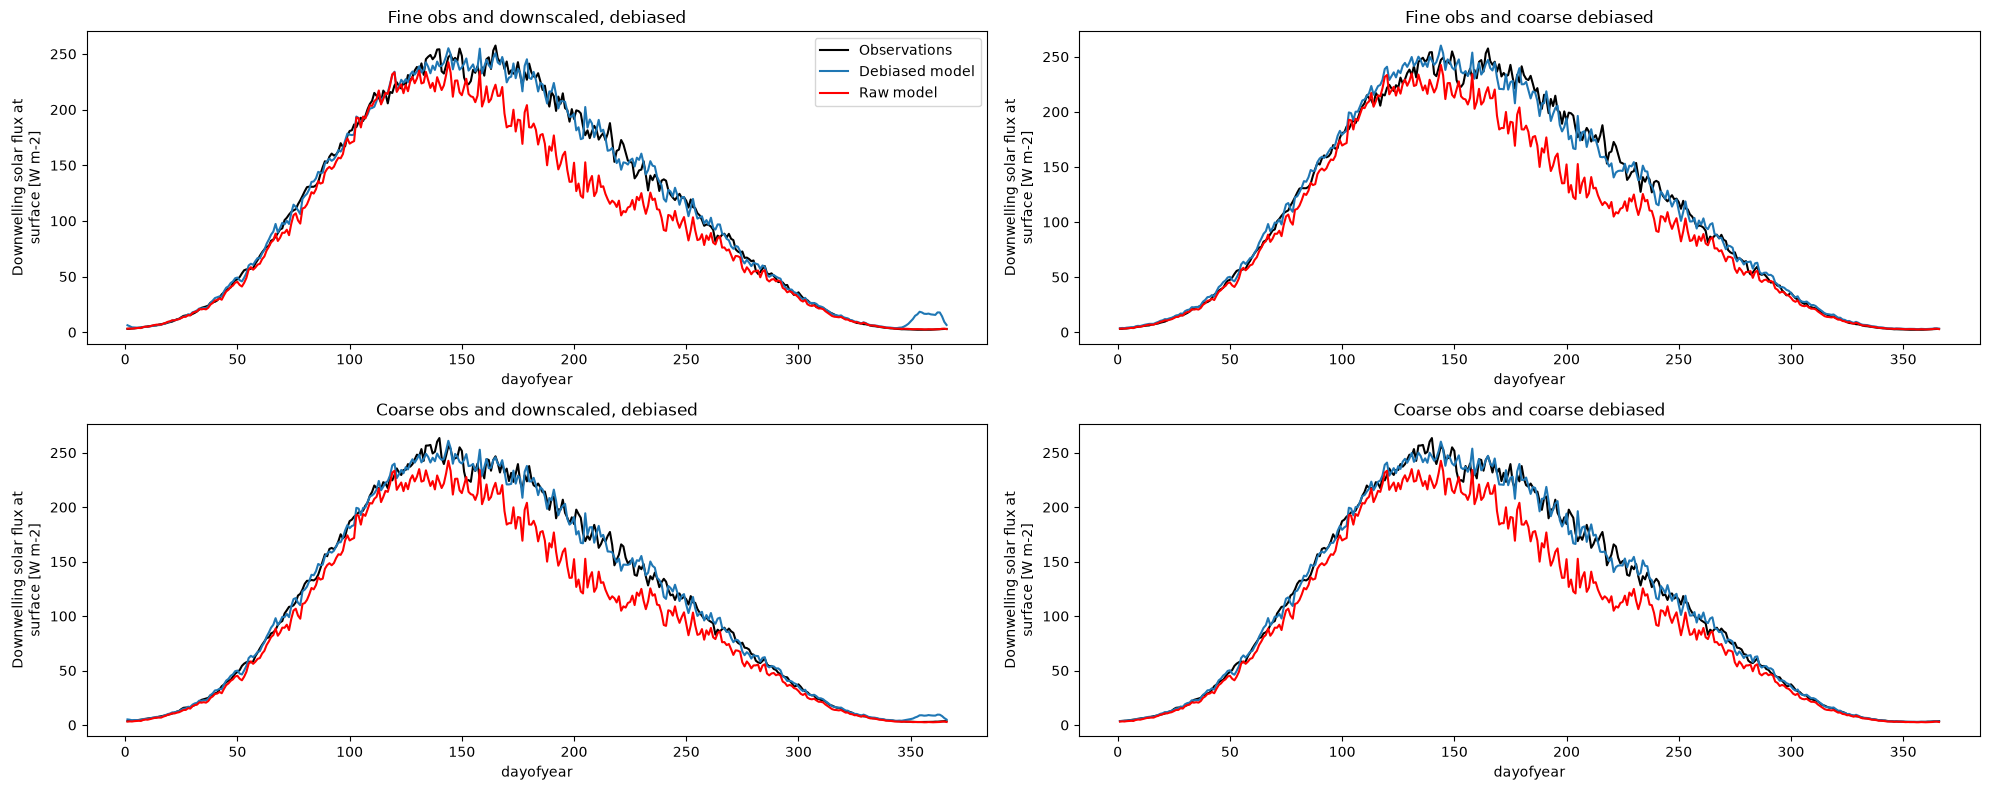

In [17]:
plt.figure(figsize=(20, 8))
plt.subplot(2, 2, 1)
obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Observations", color="k")
debiased_downscaled_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Debiased model")
raw_hist_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Raw model", color="r")
plt.legend()
plt.title("Fine obs and downscaled, debiased")
plt.subplot(2, 2, 2)
obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(color="k")
coarse_debiased_finegrid_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
raw_hist_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Raw model", color="r")
plt.title("Fine obs and coarse debiased")
plt.subplot(2, 2, 3)
obs_coarse_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(color="k")
coarsened_debiased_downscaled_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
raw_hist_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Raw model", color="r")
plt.title("Coarse obs and downscaled, debiased")
plt.subplot(2, 2, 4)
obs_coarse_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(color="k")
coarse_debiased_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot()
raw_hist_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot(label="Raw model", color="r")
plt.title("Coarse obs and coarse debiased")
plt.tight_layout()

In [18]:
coarse_debiased_pt = coarse_debiased.sel(lat=pt_lat, lon=pt_lon, method="nearest")
ds_debiased_pt = debiased_downscaled.sel(lat=pt_lat, lon=pt_lon, method="nearest")
raw_pt = raw_hist.sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
obs_fine_pt = obs_fine.sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
obs_coarse_pt = obs_coarse.sel(lat=pt_lat, lon=pt_lon, method="nearest").load()

Text(0, 0.5, 'Debiased value')

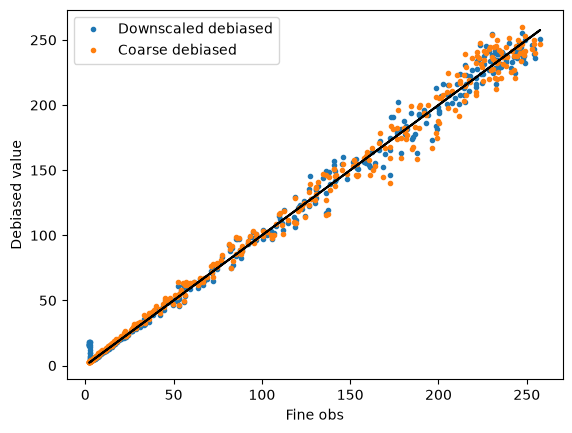

In [19]:
plt.plot(
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    debiased_downscaled_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    label="Downscaled debiased",
)
plt.plot(
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    coarse_debiased_finegrid_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    label="Coarse debiased",
)
plt.plot(
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    obs_fine_clim.sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    "-k",
)
plt.legend()
plt.xlabel("Fine obs")
plt.ylabel("Debiased value")

In [20]:
pt = dict(lat=23, lon=3, method="nearest")

metric_fine = metrics_obsfine_outputfine[eval_metric].sel(**pt)
metric_coarse = metrics_obsfine_outputcoarse[eval_metric].sel(**pt)

print("snapped to lat/lon:", float(metric_fine.lat), float(metric_fine.lon))
print(f"{metric_label}, fine obs vs. downscaled (fine) output:", float(metric_fine))
print(f"{metric_label}, fine obs vs. coarse output (upsampled):", float(metric_coarse))
print("downscaled - coarse:", float(metric_fine - metric_coarse))
print()
print("obs_fine time range:", obs_fine.time.min().values, "to", obs_fine.time.max().values)
print("time_dim (aggregation method):", time_dim)

snapped to lat/lon: 23.0 3.0
KGE, fine obs vs. downscaled (fine) output: 0.9944551587104797
KGE, fine obs vs. coarse output (upsampled): 0.9938315749168396
downscaled - coarse: 0.0006235837936401367

obs_fine time range: 1978-01-01T00:00:00.000000000 to 2014-12-31T00:00:00.000000000
time_dim (aggregation method): dayofyear


## Save results to CSV

In [21]:
def save_downscaling_improvement_csv(
    metrics_obsfine_outputfine,
    metrics_obsfine_outputcoarse,
    metrics_obscoarse_outputfine,
    metrics_obscoarse_outputcoarse,
    variable,
    scenario,
    ensemble_member,
    csv_path,
    metric=eval_metric,
):
    """Summarize downscaled-vs-coarse skill (relative to fine and coarse obs) as a long-format CSV."""
    diff_obsfine = metrics_obsfine_outputfine[metric] - metrics_obsfine_outputcoarse[metric]
    diff_obscoarse = metrics_obscoarse_outputfine[metric] - metrics_obscoarse_outputcoarse[metric]

    rows = [
        # relative to fine obs
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_downscaled_better",
            "value": float((diff_obsfine > 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_coarse_better",
            "value": float((diff_obsfine < 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": "frac_same",
            "value": float((diff_obsfine == 0).mean().values),
        },
        # relative to coarse obs
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_downscaled_better",
            "value": float((diff_obscoarse > 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_coarse_better",
            "value": float((diff_obscoarse < 0).mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": "frac_same",
            "value": float((diff_obscoarse == 0).mean().values),
        },
        # absolute metric values
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": f"mean_{metric}_outputfine",
            "value": float(metrics_obsfine_outputfine[metric].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "fine",
            "metric": f"mean_{metric}_outputcoarse",
            "value": float(metrics_obsfine_outputcoarse[metric].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": f"mean_{metric}_outputfine",
            "value": float(metrics_obscoarse_outputfine[metric].mean().values),
        },
        {
            "variable": variable,
            "scenario": scenario,
            "ensemble_member": ensemble_member,
            "obs_scale": "coarse",
            "metric": f"mean_{metric}_outputcoarse",
            "value": float(metrics_obscoarse_outputcoarse[metric].mean().values),
        },
    ]

    pd.DataFrame(rows).to_csv(csv_path, mode="w", index=False)

In [22]:
save_downscaling_improvement_csv(
    metrics_obsfine_outputfine=metrics_obsfine_outputfine,
    metrics_obsfine_outputcoarse=metrics_obsfine_outputcoarse,
    metrics_obscoarse_outputfine=metrics_obscoarse_outputfine,
    metrics_obscoarse_outputcoarse=metrics_obscoarse_outputcoarse,
    variable=var,
    scenario=scenario,
    ensemble_member=ens,
    metric=eval_metric,
    csv_path=path_qaqc + "hist_bias_comparison_" + var + "_" + scenario + "_" + ens + ".csv",
)